# Introduction

In this project, you will build a neural network of your own design to evaluate the CIFAR-10 dataset.
Our target accuracy is 70%, but any accuracy over 50% is a great start.
Some of the benchmark results on CIFAR-10 include:

78.9% Accuracy | [Deep Belief Networks; Krizhevsky, 2010](https://www.cs.toronto.edu/~kriz/conv-cifar10-aug2010.pdf)

90.6% Accuracy | [Maxout Networks; Goodfellow et al., 2013](https://arxiv.org/pdf/1302.4389.pdf)

96.0% Accuracy | [Wide Residual Networks; Zagoruyko et al., 2016](https://arxiv.org/pdf/1605.07146.pdf)

99.0% Accuracy | [GPipe; Huang et al., 2018](https://arxiv.org/pdf/1811.06965.pdf)

98.5% Accuracy | [Rethinking Recurrent Neural Networks and other Improvements for ImageClassification; Nguyen et al., 2020](https://arxiv.org/pdf/2007.15161.pdf)

Research with this dataset is ongoing. Notably, many of these networks are quite large and quite expensive to train. 

## Imports

In [1]:
## This cell contains the essential imports you will need – DO NOT CHANGE THE CONTENTS! ##
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

## Load the Dataset

Specify your transforms as a list first.
The transforms module is already loaded as `transforms`.

CIFAR-10 is fortunately included in the torchvision module.
Then, you can create your dataset using the `CIFAR10` object from `torchvision.datasets` ([the documentation is available here](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html)).
Make sure to specify `download=True`! 

Once your dataset is created, you'll also need to define a `DataLoader` from the `torch.utils.data` module for both the train and the test set.

In [2]:
# Getting an error with Jupyter Notebook Kernel shutting down. Running this cell fixes error. (Only happens when using matplotlib)
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [3]:
# DEFINING CONSTANTS
BATCH_SIZE = 32
RAND_ROTATION_ANGLE = 30
IMAGE_SIZE = (32, 32, 3) #Image Height, Image Width, Color Channels

In [4]:
# Define transforms
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# Create training set and define training dataloader
train_set = torchvision.datasets.CIFAR10(root='~/.pytorch/CIFAR_10_data/', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)

# Create test set and define test dataloader
test_set = torchvision.datasets.CIFAR10(root='~/.pytorch/CIFAR_10_data/', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

# The 10 classes in the dataset
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

## Explore the Dataset
Using matplotlib, numpy, and torch, explore the dimensions of your data.

You can view images using the `show5` function defined below – it takes a data loader as an argument.
Remember that normalized images will look really weird to you! You may want to try changing your transforms to view images.
Typically using no transforms other than `toTensor()` works well for viewing – but not as well for training your network.
If `show5` doesn't work, go back and check your code for creating your data loaders and your training/test sets.

In [5]:
def show5(img_loader):
    dataiter = iter(img_loader)
    
    batch = next(dataiter)
    labels = batch[1][0:5]
    images = batch[0][0:5]
    for i in range(5):
        print(classes[labels[i]])
    
        image = images[i].numpy()
        plt.imshow(image.T)
        plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..0.77254903].


frog


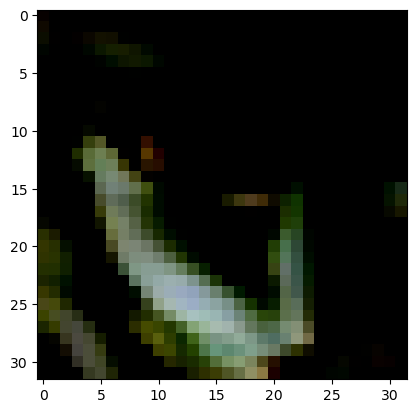

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7882353..0.45098042].


cat


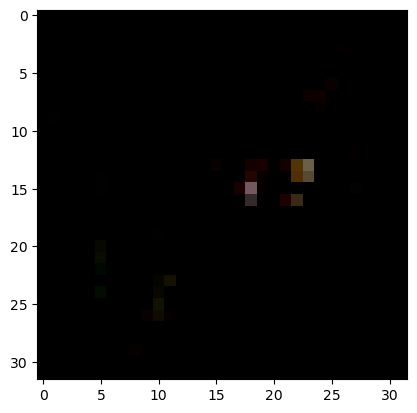

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9843137..0.9764706].


deer


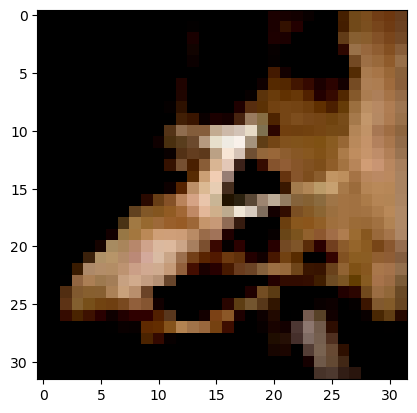

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..1.0].


bird


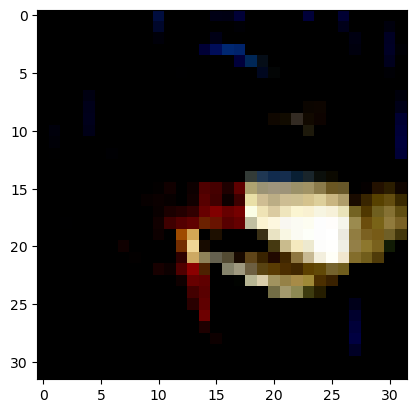

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8509804..0.4901961].


bird


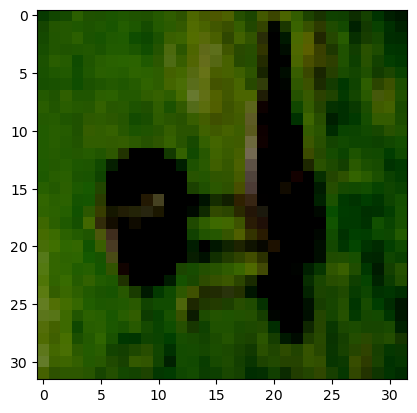

In [6]:
# Explore data
show5(train_loader);

## Build your Neural Network
Using the layers in `torch.nn` (which has been imported as `nn`) and the `torch.nn.functional` module (imported as `F`), construct a neural network based on the parameters of the dataset. 
Feel free to construct a model of any architecture – feedforward, convolutional, or even something more advanced!

In [91]:
# Network Architecture Definition
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        self.out = nn.LogSoftmax(dim=1)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        x = self.out(x)
        return x

Specify a loss function and an optimizer, and instantiate the model.

If you use a less common loss function, please note why you chose that loss function in a comment.

In [92]:
model = Classifier()
criterion = nn.NLLLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001)

In [93]:
# Sanity Check, print model
print(type(model))
print(model)

<class '__main__.Classifier'>
Classifier(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
  (out): LogSoftmax(dim=1)
)


## Running your Neural Network
Use whatever method you like to train your neural network, and ensure you record the average loss at each epoch. 
Don't forget to use `torch.device()` and the `.to()` method for both your model and your data if you are using GPU!

If you want to print your loss during each epoch, you can use the `enumerate` function and print the loss after a set number of batches. 250 batches works well for most people!

In [94]:
def get_best_cuda_device() -> torch.device:
    """
    Function to get the best cuda device
    Assumptions:    there is a CUDA device available
    Reasoning:      Can be used when a machine has more than one GPU available for example
                    As for example, my machine has an RTX4090 and an RTX5090
    Reference: # https://docs.pytorch.org/docs/stable/generated/torch.cuda.get_device_capability.html
    :return: the best cuda device based on device major cuda capability
    """

    # Get the max index of the device with the best major cuda capability
    # We use the max function with a list of the device ids (as ints)
    # and the major device capability (index 0) as the key
    best_device = max(
        range(torch.cuda.device_count()),
        key=lambda i: torch.cuda.get_device_capability(i)[0]
    )
    # Return the best cuda device, based on major device capability
    return torch.device(f"cuda:{best_device}")

def get_device(override: str = None) -> torch.device:
    """
    Function to get the device to use by PyTorch
    :param override: Optional override for device
    :return: The best device available or the overridden device
    Reference: https://mctm.web.id/blog/2024/PyTorchGPUSelect/
    """
    # Check not overriding device to use
    if not override:
        # Step 1: Check if CUDA is available
        if torch.cuda.is_available():
            # If so, return the best CUDA device
            return get_best_cuda_device()
        # Step 2: If no CUDA, check if MPS enabled machine
        elif torch.backends.mps.is_available():
            # If so, return as device
            return torch.device("mps")
        # Step 3: If no CUDA and no MPS, then we return CPU
        else:
            return torch.device("cpu")
    else:
        # Else, if we are overriding, we specifically return
        # the device given by the argument (i.e. "cpu", "cuda", "cuda:0", "mps", etc)
        return torch.device(override)

In [95]:
from timeit import default_timer as timer
from copy import deepcopy


In [96]:
def train_step(
        model: Classifier,
        dataloader: torch.utils.data.DataLoader,
        device: torch.types.Device,
        optimizer: torch.optim.Optimizer,
        criterion) -> tuple[float, float]:
    """
    Function that performs one training step
    Reference used: https://www.kaggle.com/code/tirendazacademy/cats-dogs-classification-with-pytorch
    :param dataloader: dataloader to use for training
    :return: train loss and train accuracy of the step (once per epoch)
    """

    # Put the model in train mode
    model.train()

    # Init train loss and train accuracy
    train_loss, train_correct = 0.0, 0.0

    # iterate over inputs and labels in the dataloader
    for inputs, labels in dataloader:

        # set the device
        inputs, labels = inputs.to(device), labels.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        logps = model(inputs)
        loss = criterion(logps, labels)

        # Add to the training loss
        train_loss += loss.item()

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Get the probabilities
        ps = torch.exp(logps)

        # Get the top class
        _, top_class = ps.topk(1, dim=1)

        # Get list of all equalities top_class == label
        equals: torch.Tensor = torch.Tensor(top_class == labels.view(*top_class.shape))

        # Update training corrects
        train_correct += torch.sum(equals).item()
        # print(f"Running Train Corrects: {train_correct}")

    # Calculate metrics
    train_loss = train_loss / len(dataloader.dataset)
    train_accuracy = train_correct / len(dataloader.dataset)

    return train_loss, train_accuracy

In [97]:
def valid_step(
        model: Classifier,
        dataloader: torch.utils.data.DataLoader,
        device: torch.types.Device,
        criterion) -> tuple[float, float]:
    """
    Function that performs one validation step
    Reference used: https://www.kaggle.com/code/tirendazacademy/cats-dogs-classification-with-pytorch
    :param dataloader: dataloader to use for validation
    :return: validation loss and validation accuracy of the step (once per epoch)
    """

    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    valid_loss, valid_correct = 0.0, 0.0

    # Turn on inference context manager
    with torch.no_grad():
        # Loop through DataLoader batches
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            # 1. Forward pass
            logps = model(inputs)

            # 2. Calculate and accumulate loss
            loss = criterion(logps, labels)
            valid_loss += loss.item()

            # Calculate and accumulate accuracy
            ps = torch.exp(logps)
            top_p, top_class = ps.topk(1, dim=1)
            equals: torch.Tensor = torch.Tensor(top_class == labels.view(*top_class.shape))

            # print(f"VALID EQUALS: {equals}")

            valid_correct += torch.sum(equals).item()
            # print(f"Running Valid Corrects: {valid_correct}")

    # Adjust metrics to get average loss and accuracy per batch
    valid_loss = valid_loss / len(dataloader.dataset)
    valid_acc = valid_correct / len(dataloader.dataset)
    return valid_loss, valid_acc

In [98]:
def train_results(epoch: int) -> float:
    """
    Function that prints out results one training step (one per epoch)
    and updates de results dictionary
    :param results_dict:
    :param results:
    :param epoch: the current epoch
    :return the validation accuracy of the current epoch for use in determining the best weights
    """
    # Print Results
    print(
        f"Epoch: {epoch + 1} | "
        f"train_loss: {results["train_loss"]:.4f} | "
        f"train_acc: {results["train_acc"] * 100:.2f}% | "
        f"valid_loss: {results["valid_loss"]:.4f} | "
        f"valid_acc: {results["valid_acc"] * 100:.2f}%"
    )

    # Update Results dict by appending the new values
    results_dict["train_loss"].append(results["train_loss"])
    results_dict["train_acc"].append(results["train_acc"])
    results_dict["valid_loss"].append(results["valid_loss"])
    results_dict["valid_acc"].append(results["valid_acc"])

    return results["valid_acc"]

In [99]:
# init results and results_dict
results = {
    "train_loss": 0,
    "train_acc": 0,
    "valid_loss": 0,
    "valid_acc": 0
}

results_dict = {
    "train_loss": [],
    "train_acc": [],
    "valid_loss": [],
    "valid_acc": []
}

In [100]:
def train(model: Classifier,
        dataloaders: torch.utils.data.DataLoader,
        device: torch.types.Device,
        optimizer: torch.optim.Optimizer,
        criterion,
        num_epochs=10) -> dict[str, float]:
    """
    Function that trains the model
    :param dataloaders: dataloaders to use for training and validation
    :param num_epochs: number of epochs to train for
    :return: dictionary of the results of the training
    """

    # set the device
    model.to(device)

    # for the start time
    start_time = None

    # init best_state_dict to the initial state_dict (not trained)
    best_state_dict = deepcopy(model.state_dict())

    # to keep track of best accuracy
    best_acc = 0.0

    # I happened to use a library called tqdm to show a progress bar
    # One can install it if they want
    # Here we check if we have it installed and then use it
    try:
        from tqdm.auto import tqdm
        print("'tqdm' found")

        # get the start time
        start_time = timer()

        # iterate over each epoch and perform the training and validation steps
        for epoch in tqdm(range(num_epochs)):
            results["train_loss"], results["train_acc"] = train_step(model, dataloaders["train"], device, optimizer, criterion)
            results["valid_loss"], results["valid_acc"] = valid_step(model, dataloaders["valid"], device, criterion)

            # show the results and get the accuracy
            epoch_acc = train_results(epoch)

            # if we have better accuracy, then we set the new best_state_dict
            # and the new better accuracy
            if epoch_acc > best_acc:
                best_state_dict = deepcopy(model.state_dict())
                best_acc = epoch_acc

    # if tqdm not installed, default to not using it...
    # and do the same steps as above
    # this can be factored into a function, but for now I will leave it as is
    except ModuleNotFoundError:

        print("'tqdm' not found, using normal range function")

        start_time = timer()

        for epoch in range(num_epochs):
            results["train_loss"], results["train_acc"] = train_step(model, dataloaders["train"], device, optimizer, criterion)
            results["valid_loss"], results["valid_acc"] = valid_step(model, dataloaders["valid"], device, criterion)

            epoch_acc = train_results(epoch)

            if epoch_acc > best_acc:
                best_state_dict = deepcopy(model.state_dict())
                best_acc = epoch_acc

    # training complete, get the end time and show
    end_time = timer()
    elapsed_time = end_time - start_time
    print(f"Training Complete! Total training time: {elapsed_time} seconds")

    # Save best training weights
    model.load_state_dict(best_state_dict)

    # return the results dictionary (can be used for plotting)
    return results_dict, best_state_dict

In [101]:
dataloaders = {
    "train": train_loader,
    "valid": test_loader
}

print(dataloaders)

device = get_device()
print(device)

{'train': <torch.utils.data.dataloader.DataLoader object at 0x0000020E24ACFB60>, 'valid': <torch.utils.data.dataloader.DataLoader object at 0x0000020E24AE5090>}
cuda:1


In [102]:
training_results, best_state = train(model, dataloaders, device, optimizer, criterion, num_epochs=25);
print(training_results)

'tqdm' found


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.0720 | train_acc: 10.00% | valid_loss: 0.0720 | valid_acc: 10.00%
Epoch: 2 | train_loss: 0.0719 | train_acc: 10.14% | valid_loss: 0.0719 | valid_acc: 10.91%
Epoch: 3 | train_loss: 0.0718 | train_acc: 13.28% | valid_loss: 0.0718 | valid_acc: 15.90%
Epoch: 4 | train_loss: 0.0716 | train_acc: 16.74% | valid_loss: 0.0715 | valid_acc: 16.77%
Epoch: 5 | train_loss: 0.0711 | train_acc: 16.92% | valid_loss: 0.0707 | valid_acc: 16.45%
Epoch: 6 | train_loss: 0.0701 | train_acc: 18.13% | valid_loss: 0.0695 | valid_acc: 19.71%
Epoch: 7 | train_loss: 0.0687 | train_acc: 21.26% | valid_loss: 0.0678 | valid_acc: 22.51%
Epoch: 8 | train_loss: 0.0669 | train_acc: 22.89% | valid_loss: 0.0657 | valid_acc: 24.05%
Epoch: 9 | train_loss: 0.0652 | train_acc: 24.02% | valid_loss: 0.0642 | valid_acc: 26.04%
Epoch: 10 | train_loss: 0.0639 | train_acc: 25.58% | valid_loss: 0.0629 | valid_acc: 27.11%
Epoch: 11 | train_loss: 0.0626 | train_acc: 27.00% | valid_loss: 0.0618 | valid_acc: 28.1

Plot the training loss (and validation loss/accuracy, if recorded).

In [ ]:
## YOUR CODE HERE ##

## Testing your model
Using the previously created `DataLoader` for the test set, compute the percentage of correct predictions using the highest probability prediction. 

If your accuracy is over 70%, great work! 
This is a hard task to exceed 70% on.

If your accuracy is under 45%, you'll need to make improvements.
Go back and check your model architecture, loss function, and optimizer to make sure they're appropriate for an image classification task.

In [ ]:
## YOUR CODE HERE ##

## Saving your model
Using `torch.save`, save your model for future loading.

In [ ]:
## YOUR CODE HERE ##

## Make a Recommendation

Based on your evaluation, what is your recommendation on whether to build or buy? Explain your reasoning below.



**Double click this cell to modify it**

